# Pre-class Assignment 9

**Due Tuesday night of Week 9**

#### &#9989; Owen Sliger

---

## Narrowing the Search for Particles

You've spent some time working with a data set of two-muon detections. We will use the data set as a context to learn about particle physics, and to identify parent particles that likely decayed into the muons that were detected.

&#9989; **Do this:** Add code below to **compute invariant mass** and **make a histogram** of the invariant mass distribution.

*Hint: See PCA 8 for more details on invariant mass.*

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/MuRun2010B.csv", skiprows=5)

df['Q_sum'] = df['Q1'] + df['Q2']

df['E'] = df['E1'] + df['E2']
df['px'] = df['px1 '] + df['px2']
df['py'] = df['py1'] + df['py2']
df['pz'] = df['pz1'] + df['pz2']

df['inv_m'] = (df['E']**2 - (df['px']**2 + df['py']**2 + df['pz']**2))**0.5

dat = df[df['Q_sum'] == 0]
noise = df[df['Q_sum'] != 0]

dat['inv_m'].describe()

count    63946.000000
mean         9.965284
std         10.815578
min          1.998699
25%          3.114147
50%          7.398313
75%         12.607757
max        109.977130
Name: inv_m, dtype: float64

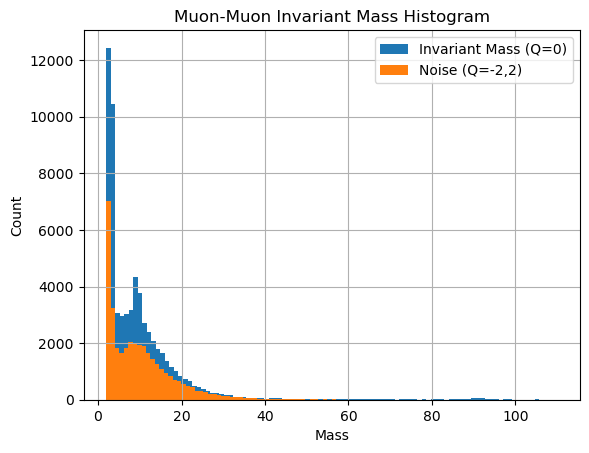

In [24]:
plt.hist(dat['inv_m'],bins=100, label='Invariant Mass (Q=0)')
plt.hist(noise['inv_m'],bins=100, label='Noise (Q=-2,2)')
plt.legend()
plt.xlabel('Mass')
plt.ylabel('Count')
plt.title('Muon-Muon Invariant Mass Histogram')
plt.grid()

Watch the video below for an explanation of how we can interpret the peaks in the histogram.

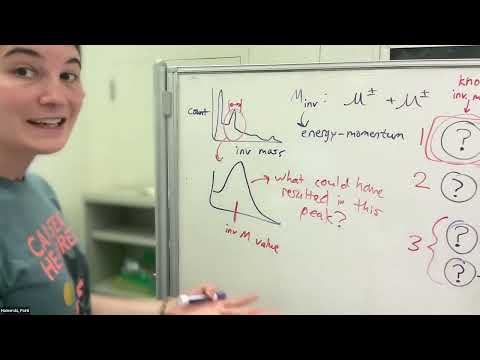

In [10]:
from IPython.display import YouTubeVideo
YouTubeVideo("TSXbbw0VXt0", width=600, height=350)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_rwhlnb5r

For the tasks below, imagine we had a **double-electron data set** -- that would include detections of two electrons/positrons in each event. We don't have this data set or histogram, but you can reason about what you might be able to find in it.

&#9989; **Do this:** Suppose there is a particle $X$ that primarily follows the decay shown below. The theoretical mass of the particle is 40 GeV/$c^2$. How could you use this information to interpret the data set?

$$X \rightarrow e^- + e^+$$

We could see if there is a peak in invariant mass of the sum of electrons when their total change is equal to zero at 40 GeV/$c^2$ to show that the electron pairs are being generated by the decay of particle X.

&#9989; **Do this:** Suppose there is a particle $Y$ that primarily follows the decay shown below. The theoretical mass of the particle is 15 GeV/$c^2$. How could you use this information to interpret the data set?

$$Y \rightarrow e^- + e^+ + \nu_e + \bar{\nu}_e$$

Since we are only measuring the electrons, we would see that the invariant mass caused by this decay would be smaller than 15 GeV/$c^2$, since we cannot measure the energy lost due to the neutrinos. So, there would be a peak represting the decay of Y, but the amount of invariant mass would not match like it did with the decay of X.

---

## Filtering the Data Set

Above, we reasoned about what types of parent particles could be identifiable in a data set based on events focused only on a narrow set of decay products. There are a couple takeaways to keep in mind:
- We can only identify parent particles for which **every** decay product can be captured in an event.
- Conservation of energy-momentum (i.e., invariant mass) helps us predict the invariant mass of parent particles from its decay products.

We can also narrow our search for parent particles based on other conservation laws, such as charge. Every event in our data set has a total charge of -2, 0, or 2. Since we are looking for events that represent the decay of a single parent particle, we can immediately ignore some of the events -- there are no particles, or even bound states of particles, that have a charge of -2 or 2.

Once we can reason about which events we want to focus on, we can filter the data set to narrow our search even more. See the video below for how to implement this.

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo("fQ7nUIPqgC0", width=600, height=350)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_j0d2yo9d

&#9989; **Do this:** Filter the data set to only events with M > 50. Create a histogram to show the invariant mass distribution of this filtered data.

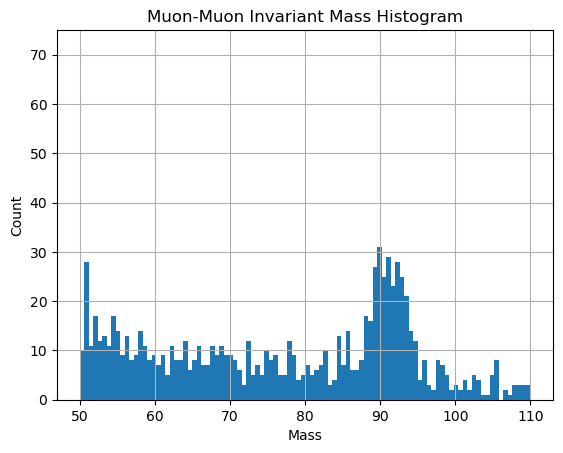

In [20]:
plt.hist(df['inv_m'],bins=100, label='Invariant Mass',range=(50,110))
plt.axis(ymax=75)
plt.xlabel('Mass')
plt.ylabel('Count')
plt.title('Muon-Muon Invariant Mass Histogram')
plt.grid()

&#9989; **Do this:** Filter the data set to only events with total charge 0. Create a histogram to show the invariant mass distribution of this filtered data.

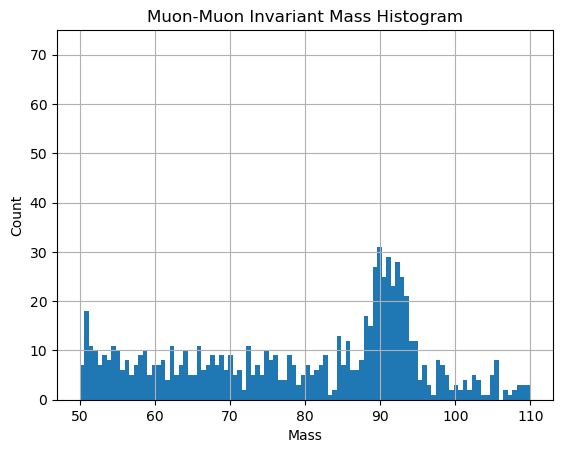

In [23]:
plt.hist(dat['inv_m'],bins=100, label='Invariant Mass',range=(50,110))
plt.axis(ymax=75)
plt.xlabel('Mass')
plt.ylabel('Count')
plt.title('Muon-Muon Invariant Mass Histogram')
plt.grid()

&#9989; **Do this:** Filter the data set to only events with total charge **nonzero.** Create a histogram to show the invariant mass distribution of this filtered data. **Also** include the histogram from the previous task, to show how the two filtered data sets compare. Add labels to each plot to distinguish between them.

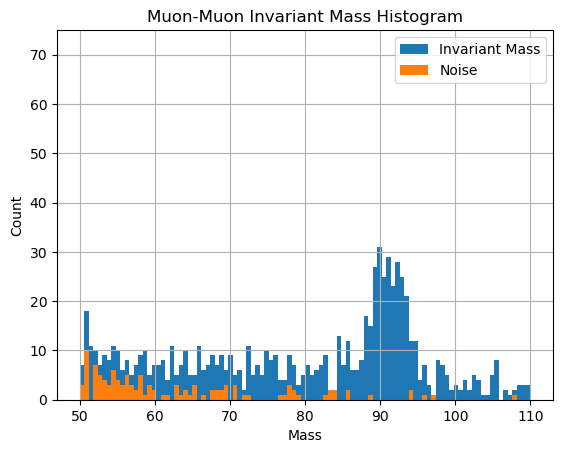

In [22]:
plt.hist(dat['inv_m'],bins=100, label='Invariant Mass',range=(50,110))
plt.hist(noise['inv_m'],bins=100, label='Noise',range=(50,110))
plt.legend()
plt.axis(ymax=75)
plt.xlabel('Mass')
plt.ylabel('Count')
plt.title('Muon-Muon Invariant Mass Histogram')
plt.grid()

&#9989; **Do this:** Based on the visualization you created above, how does the $Q_\text{total} = 0$ filtered data compare to the $Q_\text{total} = \pm 2$ filtered data?

The filtered Q=0 data is interestingly unchanged at an invariant mass of around 85-95. Unlike other sections, which have noise following an inverse exponential with similar peaks (Shown in the very first graph), the peak shown in the filtered data is only present when Q=0. 

---

## Identifying Parent Particles

Now we have applied both the conservation of energy-momentum **and** the conservation of charge to visualize and filter the data we have been working with. You should be able to point to a few peaks in the invariant mass distribution. Now, how can we figure out which parent particle might have decayed to result in this "signature" of muons that we detected?

For each peak in the mass distribution, we can make a couple claims:

- The mass of the parent particle should be where the peak is.
- The charge of the parent particle should be 0.

We can also take a look at other conserved quantities, like spin and lepton number. To do that, it can help to familiarize with the particles that are part of the standard model.

The standard model contains leptons, bosons, and quarks. Leptons and bosons can exist on their own and singular particles, whereas quarks have only been observed to exist in bound states of 2 or 3 quarks together.

&#9989; **Do this:** Fill out the table of quantities that describe leptons, bosons, and their antiparticles.

*Antiparticles have opposite charge and lepton number as their corresponding particles, but they have the same value of spin.*

Table of bosons, leptons, and their antiparticles.

| Particle | Symbol | Charge | Spin | Lepton number |
|----------|--------|--------|------|---------------|
| **Leptons** |||||
| electron | $e^-$ | -1 | 1/2 | 1 |
| positron | $e^+$ | 1 | 1/2 | -1 |
| electron neutrino | $\nu_e$ | 0 | 1/2 | 1 |
| electron antineutrino | $\bar{\nu}_e$ | 0 | 1/2 | -1 |
| muon | $\mu^-$ | -1 | 1/2 | 1 |
| antimuon | $\mu^+$ | +1 | 1/2 | -1 |
| muon neutrino | $\nu_\mu$ | 0 | 1/2 | 1 |
| muon antineutrino | $\bar{\nu}_\mu$ | 0 | 1/2 | -1 |
| **Bosons** |||||
| W$^+$ boson | $W^+$ | 1 | 1 | 0 |
| W$^-$ boson | $W^-$ | -1 | 1 | 0 |
| Z boson | $Z^0$ | 0 | 1 | 0 |

&#9989; **Do this:** The Z boson, unlike the other particles in the table, does not have an antiparticle listed below it. What would be the characteristics of the Z boson's antiparticle?

It would have the exact same properties as the Z boson, since the lepton number and charge are both 0, and spin doesnt change.

&#9989; **Do this:** What is the total charge, spin, and lepton number of a muon-antimuon pair?

the total charge, spin, and lepton number would be: 0, 1, 0

To get familiar with bound states of quarks, we can start with single quarks. Although we don't expect any single quarks to be identifiable, it's easier to learn a little about the single quarks before looking into their bound states.

Single quarks and antiquarks have a "baryon number." This is another conserved quantity. It is analagous to lepton number, because every quark has a baryon number of 1/3, and every antiquark will have the opposite.

&#9989; **Do this:** Fill out the table of quantities that describe quarks and antiquarks.

| Particle | Symbol | Charge | Spin | Baryon number | Lepton number |
|----------|--------|--------|------|---------------|---------------|
| Down quark | $d$ | -1/3 | 1/2 | 1/3 | 0 |
| Down antiquark | $\bar{d}$ | 1/3 | 1/2 | -1/3 | 0 |
| Up quark | $u$ | 2/3 | 1/2 | 1/3 | 0 |
| Up antiquark | $\bar{u}$ | -2/3 | 1/2 | -1/3 | 0 |
| Strange quark | $s$ | -1/3 | 1/2 | 1/3 | 0 |
| Strange antiquark | $\bar{s}$ | 1/3 | 1/2 | -1/3 | 0 |
| Charm quark | $c$ | 2/3 | 1/2 | 1/3 | 0 |
| Charm antiquark | $\bar{c}$ | -2/3 | 1/2 | -1/3 | 0 |
| Bottom quark | $b$ | -1/3 | 1/2 | 1/3 | 0 |
| Bottom antiquark | $\bar{b}$ | 1/3 | 1/2 | -1/3 | 0 |
| Top quark | $t$ | 2/3 | 1/2 | 1/3 | 0 |
| Top antiquark | $\bar{t}$ | -2/3 | 1/2 | -1/3 | 0 |


Quarks exist in bound states. Three quarks is a baryon. A quark-antiquark pair is a meson. 

&#9989; **Do this:** You identified charge, spin, and lepton number of the muon-antimuon pair. Among baryons and mesons, which type of quark bound state could be a possible parent particle of the muon-antimuon pair?

*Hint: All leptons have a baryon number of 0. Baryon number is another quantity that is conserved across parent particles and their decay products.*

The particle cant be made of 3 quarks (like a proton) (I had to look up why a proton has a spin of 1/2, and I think its because three quarks lead to two of them canceling their spins out, leaving the proton with 1/2?) since the spin would be 1/2 instead of 1. So, the only combinations that work are pair with opposite baryon number and charge such that the charge is 0, the spin is 1, and the baryon number is 0.

When multiple quarks enter a bound state, figuring out its properties is not always as easy as adding two numbers together.
- For **charge,** the charge values of each quark adds together nicely. The charge of a meson or baryon is simply the sum of the charges of its component quarks.
- For **spin,** the creation of the bound state can cause one or more spins to re-align. For example, a meson composed of two spin-1/2 particles (a quark and an antiquark) can have one particle with spin = -1/2, so that they can be paired in a singlet state. However, the meson could also exist with both particles keeping spin = 1/2, with the meson's total spin = 1.
- This is possible because **angular momentum is conserved,** not spin. When particles exist in bound states like a meson or a baryon, it can have an angular momentum separate from spin alone.

You can see more information about quarks and their bound states here: https://openstax.org/books/university-physics-volume-3/pages/11-3-quarks

Suppose we gathered a data set of **muon and muon antineutrino** detections. That is:

$$? \rightarrow \mu^- + \bar{\nu}_\mu$$

&#9989; **Do this:** What is the charge, spin, lepton number, and baryon number of the possible parent particle? **Also,** name one meson or baryon that could have decayed into these products.

*Hint: Look into the link above for info about specific mesons and baryons.*

charge: -1, spin: 1, baryon number: 0. A possible meson that decayed into these is the Negative rho, as it is a combinations of an up antiquark and a down quark, with charge: -1, spin: 1, baryon nuber: 0.

---

### That's all! You've reached the end of the pre-class assignment.

Scroll through to make sure you didn't miss any tasks (marked with &#x2705;). Download your work as an HTML file, by selecting: `File` --> `Save and Export Notebook As...` --> `HTML` inside the JupyterHub interface (don't select your browser's File menu). 

Open your downloaded file to ensure the contents look okay, then submit it on Canvas.